In [1]:
from typing import List, Union, Tuple
import numpy as np
import cv2
import matplotlib.pyplot as plt

### Utils

In [2]:
def show_images(
    images : Union[np.ndarray, List[np.ndarray]],
    titles : Union[str, List[str]] = '',
    ncols  : int = 3,
    figsize: Tuple[int, int] = (15, 10)
) -> None:
    if isinstance(images, np.ndarray):
        images = [images]
    if isinstance(titles, str):
        titles = [titles]

    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols if n >= ncols else n,
        figsize=figsize
    )
    axes = np.array([axes]).flatten() if n == 1 else np.array(axes).flatten()

    for i, ax in enumerate(axes):
        if i < n:
            img = images[i]
            if img.ndim == 3:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            else:
                ax.imshow(img, cmap='gray')
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### Hybrid pipeline — Color ROI (stage 1) → Long-line projection (stage 2)

**Tại sao hybrid:**
- Projection trên full image thất bại: text panel / UI bars tạo peaks giả → outermost bắt nhầm.
- Color mask một mình thất bại: bắt được *panel* beige (gồm label, padding) chứ không phải *grid*.

**Stage 1 — Color segmentation:** board có màu beige đồng nhất `HSV≈(23,29,245)`,
background tối `V≈45`. `inRange` → mask → contour lớn nhất = panel ROI.
Loại bỏ hoàn toàn text panel, UI bars, avatars khỏi các bước sau.

**Stage 2 — Long-line projection bên trong ROI:** grid lines là pixel *tối* trên nền beige.
Erode 1D với kernel dài (`ROI_width // 3`):
- Border lines của grid (liền mạch, dài) → sống sót.
- Label chữ/số, quân cờ, line bị quân cắt đứt → bị xóa.

Outermost surviving lines = board boundary — không cần threshold ratio, không cần smooth.

In [3]:
def board_roi_by_color(
    img    : np.ndarray,
    hsv_lo : tuple[int, int, int] = (13, 9, 195),
    hsv_hi : tuple[int, int, int] = (33, 49, 255),
    close_k: int = 15,
) -> tuple[tuple[int, int, int, int] | None, np.ndarray]:
    """
    Stage 1 — find the board panel ROI by its uniform color.

    Returns ((x, y, w, h), mask). ROI is None if no region found.
    Tune hsv_lo/hi by sampling the board BACKGROUND color (click empty cells,
    NOT grid lines) using tool/color_picker.py.
    Assert fill ratio >= 0.05; if lower, the range is hitting lines, not background.
    """
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array(hsv_lo), np.array(hsv_hi))
    k    = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k, close_k))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, mask
    c = max(contours, key=cv2.contourArea)
    return cv2.boundingRect(c), mask


def _extract_bands(idx: np.ndarray) -> list[int]:
    """Group consecutive indices into bands (one band ≈ one grid line, 2–3px thick)."""
    if idx.size == 0:
        return []
    return [int(np.mean(b)) for b in np.split(idx, np.where(np.diff(idx) > 2)[0] + 1)]


def _trim_lattice(bands: list[int], tol: float = 0.25) -> list[int]:
    """Drop edge bands whose gap to neighbour deviates from median pitch by > tol.
    Removes outer frame/border lines that aren't part of the grid lattice."""
    while len(bands) > 3:
        d = np.diff(bands)
        pitch = float(np.median(d))
        if   abs(d[0]  - pitch) > tol * pitch: bands = bands[1:]
        elif abs(d[-1] - pitch) > tol * pitch: bands = bands[:-1]
        else: break
    return bands


def _strip_density(dark: np.ndarray, bands: list[int], axis: str,
                   i0: int, i1: int, pad: int = 3) -> float:
    """Dark-pixel density in the strip between bands[i0] and bands[i1].
    Label strips (text) are denser than empty cell strips."""
    a, b = bands[i0] + pad, bands[i1] - pad
    s = dark[:, a:b] if axis == 'col' else dark[a:b, :]
    return float(s.mean() / 255) if s.size else 0.0


def grid_bounds_in_roi(
    img          : np.ndarray,
    roi          : tuple[int, int, int, int],
    bg_delta     : int   = 10,
    min_len_frac : float = 0.25,
) -> tuple[np.ndarray | None, np.ndarray, np.ndarray, int]:
    """
    Stage 2 — inside the ROI, grid lines are dark pixels on the beige panel.

    Changes vs. original:
    - Adaptive threshold: bg = median(ROI) → threshold = bg - bg_delta.
      Robust across themes; hard threshold 200 fails when line intensity ≈ 200.
    - min_len_frac = 0.25 (was 1/3) — tolerates lines interrupted by pieces.
    - Returns band list + pitch, not just outermost corners.
      Trims frame lines (gap ≠ pitch) and excess label bands (density check).
      Auto-counts N_LINES = round(span/pitch) + 1.

    Returns (corners TL/TR/BR/BL, vert, horiz, n_lines).
    """
    x, y, w, h = roi
    gray = cv2.cvtColor(img[y:y+h, x:x+w], cv2.COLOR_BGR2GRAY)
    bg   = int(np.median(gray))
    dark = cv2.inRange(gray, 0, bg - bg_delta)

    min_len = max(int(w * min_len_frac), 10)
    vert  = cv2.erode(dark, cv2.getStructuringElement(cv2.MORPH_RECT, (1, min_len)))
    horiz = cv2.erode(dark, cv2.getStructuringElement(cv2.MORPH_RECT, (min_len, 1)))

    rb = _extract_bands(np.where(horiz.sum(axis=1) > 0)[0])
    cb = _extract_bands(np.where(vert.sum(axis=0)  > 0)[0])
    if len(rb) < 2 or len(cb) < 2:
        return None, vert, horiz, 0

    rb, cb = _trim_lattice(rb), _trim_lattice(cb)

    # Board is square → row count == col count; drop the denser edge (label strip)
    while len(cb) > len(rb) and len(cb) > 2:
        cb = cb[1:] if _strip_density(dark, cb, 'col', 0, 1) \
             > _strip_density(dark, cb, 'col', -2, -1) else cb[:-1]
    while len(rb) > len(cb) and len(rb) > 2:
        rb = rb[1:] if _strip_density(dark, rb, 'row', 0, 1) \
             > _strip_density(dark, rb, 'row', -2, -1) else rb[:-1]

    pitch   = float(np.median(np.r_[np.diff(rb), np.diff(cb)]))
    n_lines = round(((rb[-1] - rb[0]) + (cb[-1] - cb[0])) / (2 * pitch)) + 1

    top, bottom = y + rb[0], y + rb[-1]
    left, right = x + cb[0], x + cb[-1]
    corners = np.array(
        [[left, top], [right, top], [right, bottom], [left, bottom]],
        dtype=np.float32
    )
    return corners, vert, horiz, n_lines


def find_board(img: np.ndarray, **kwargs) -> tuple[np.ndarray | None, dict]:
    """Full hybrid pipeline. Returns (corners, debug dict)."""
    roi, mask = board_roi_by_color(img,
        hsv_lo  = kwargs.get('hsv_lo',  (13, 9, 195)),
        hsv_hi  = kwargs.get('hsv_hi',  (33, 49, 255)),
        close_k = kwargs.get('close_k', 15),
    )
    if roi is None:
        return None, {'mask': mask, 'roi': None, 'vert': None, 'horiz': None, 'n_lines': 0}

    corners, vert, horiz, n_lines = grid_bounds_in_roi(img, roi,
        bg_delta     = kwargs.get('bg_delta',     10),
        min_len_frac = kwargs.get('min_len_frac', 0.25),
    )
    return corners, {'mask': mask, 'roi': roi, 'vert': vert, 'horiz': horiz, 'n_lines': n_lines}

### Grid computation

In [4]:
def sort_corners(pts: np.ndarray) -> np.ndarray:
    """Return corners in order: TL, TR, BR, BL."""
    s = pts.sum(axis=1)               # x+y: min=TL, max=BR
    d = np.diff(pts, axis=1).flatten()  # y-x: min=TR, max=BL
    return np.array([pts[s.argmin()], pts[d.argmin()], pts[s.argmax()], pts[d.argmax()]])


def compute_grid(corners: np.ndarray, rows: int, cols: int) -> np.ndarray:
    """
    Bilinear interpolation of grid intersections from 4 board corners.
    Returns shape (rows, cols, 2) — pixel coordinates.
    """
    tl, tr, br, bl = sort_corners(corners.reshape(4, 2).astype(np.float32))
    grid = np.zeros((rows, cols, 2), dtype=np.float32)
    for r, h in enumerate(np.linspace(0, 1, rows)):
        left  = tl + h * (bl - tl)
        right = tr + h * (br - tr)
        for c, v in enumerate(np.linspace(0, 1, cols)):
            grid[r, c] = left + v * (right - left)
    return grid

### Main

In [5]:
IMG_PATH = r'image/20260612-045218.png'

img = cv2.imread(IMG_PATH)
assert img is not None, f'Cannot load {IMG_PATH}'

corners, dbg = find_board(
    img,
    hsv_lo       = (13, 9, 195),   # nền board beige — sample bằng color_picker nếu đổi theme
    hsv_hi       = (33, 49, 255),
    bg_delta     = 10,
    min_len_frac = 0.25,
)

roi_vis = img.copy()
if dbg['roi'] is not None:
    x, y, w, h = dbg['roi']
    cv2.rectangle(roi_vis, (x, y), (x + w, y + h), (0, 0, 255), 3)

show_images(
    [dbg['mask'], roi_vis, dbg['vert'], dbg['horiz']],
    ['Stage 1: color mask', 'Panel ROI (red)',
     'Stage 2: long vertical', 'Stage 2: long horizontal'],
    ncols=4, figsize=(20, 6)
)

[ WARN:0@0.313] global loadsave.cpp:278 findDecoder imread_('image/20260612-045218.png'): can't open/read file: check file path/integrity


AssertionError: Cannot load image/20260612-045218.png

TL=[14. 13.]  BR=[515. 514.]  size=501x501  aspect=1.000  lines=18x18


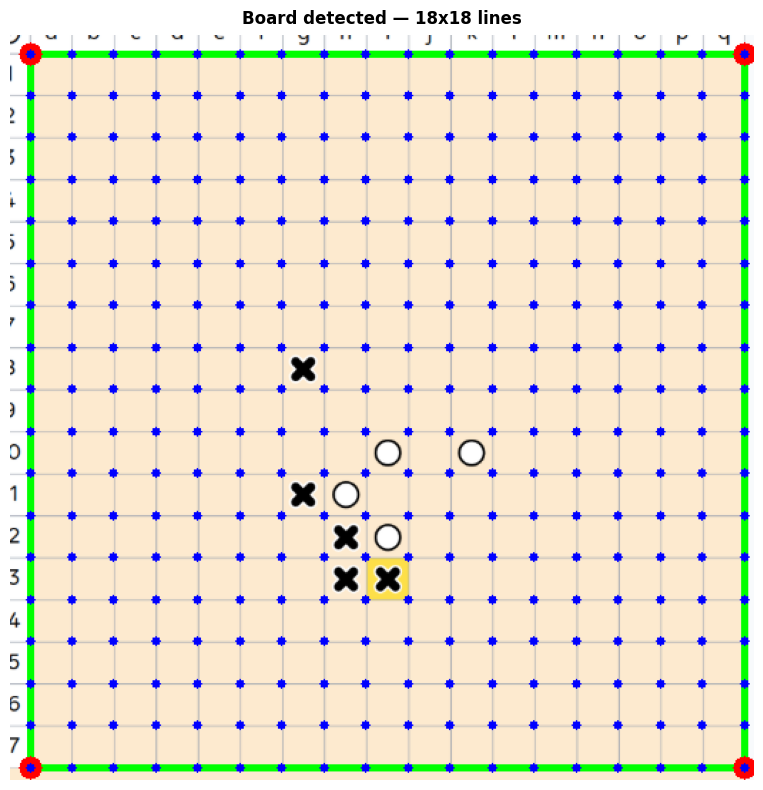

In [ ]:
if corners is None:
    print('Board not found — kiểm tra debug images:')
    print('  mask trống/fill<5%  → tune hsv_lo/hi (sample nền, không sample line)')
    print('  vert/horiz trống    → giảm min_len_frac hoặc tăng bg_delta')
else:
    tl, tr, br, bl = sort_corners(corners)
    w_b, h_b = br[0] - tl[0], br[1] - tl[1]
    N = dbg['n_lines']
    print(f'TL={tl}  BR={br}  size={w_b:.0f}x{h_b:.0f}  aspect={min(w_b,h_b)/max(w_b,h_b):.3f}  lines={N}x{N}')

    result = img.copy()
    pts_int = corners.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(result, [pts_int], isClosed=True, color=(0, 255, 0), thickness=3)
    for pt in corners:
        cv2.circle(result, tuple(pt.astype(int)), 8, (0, 0, 255), -1)

    grid = compute_grid(corners, N, N)
    for r in range(N):
        for c in range(N):
            cv2.circle(result, tuple(grid[r, c].astype(int)), 3, (255, 0, 0), -1)

    show_images(result, f'Board detected — {N}x{N} lines', figsize=(10, 8))

In [ ]:
# --- Tuning: sample HSV của board khi đổi theme/game khác ---
# Click toạ độ (x, y) bên trong ô trống (không phải grid line) rồi điền vào đây.
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H_img, W_img = img.shape[:2]
sample_points = [(min(200, W_img-1), min(300, H_img-1)),
                 (min(400, W_img-1), min(200, H_img-1)),
                 (min(300, W_img-1), min(400, H_img-1))]

for x, y in sample_points:
    print(f'({x},{y})  HSV={tuple(int(v) for v in hsv_img[y, x])}')
# → đặt hsv_lo/hi = (H±10, S±20, V±50) quanh giá trị sample

(200,300)  HSV=(18, 46, 253)
(400,200)  HSV=(18, 46, 253)
(300,400)  HSV=(18, 46, 253)
